In [1]:
import import_before_profile

In [3]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow_probability.substrates import jax as tfp

from qdots_qll.data import Data
from qdots_qll.distributions import (
    Distribution,
)
from qdots_qll.exp_design import GameExpDesignFullAdaptivity, RandExpDesignGAME
from qdots_qll.experiments import ExperimentSingleDotWeakCouplingGAME
from qdots_qll.models.single_dot_weak_coupling_GAME import (
    SingleDotWeakCouplingGAME,
)
from qdots_qll.resamplers import LiuWestResampler, MetropolisSampler
from qdots_qll.smc import SMCUpdater, replace_single_datum, replace_single_exp


In [4]:
from jaxtyping import Array

from qdots_qll.distributions import update_log_weights


def _do_not_resample(key, dist: Distribution, *args, **kwargs):
    return key, dist


def _resample(key, dist, iteration, data, resampler, *args, **kwargs):
    key, subkey = jax.random.split(key)
    new_dist: Distribution = resampler.resample(
        subkey=subkey,
        index_data=iteration,
        distribution=dist,
        data=data,
    )
    return key, new_dist


@jax.jit
def step(
    key: Array,
    iteration: int,
    distribution: Distribution,
    data: Data,
    prob_initial_state,
    prob_measurement_basis,
    *args,
    **kwargs,
) -> tuple[Array, Distribution]:
    # generate experiment
    # Measure experiment
    # create datum
    # append to data
    # update distribution
    # resample if necessary
    key, subkey = jax.random.split(key)
    # experiment = e1
    experiment, opt_prob_initial_state, opt_prob_measurement_basis = (
        exp_design.generate_experiment(
            model=model,
            distribution=distribution,
            data=data,
            subkey=subkey,
            prob_initial_state=prob_initial_state,
            prob_measurement_basis=prob_measurement_basis,
        )
    )

    key, subkey = jax.random.split(key)

    outcome = model.measure_one_experiment(subkey, experiment)
    datum = Data(experiment, outcome)

    log_lkl = model.log_lkl_datum_multiple_particles(
        distribution.particles_locations, datum
    )

    data = replace_single_datum(data, datum, iteration)

    distribution: Distribution = update_log_weights(
        dist=distribution, new_log_lkl=log_lkl
    )

    key, subkey = jax.random.split(key)
    key, distribution = jax.lax.cond(
        distribution.check_resampling(),
        _resample,
        _do_not_resample,
        *(key, distribution, iteration, data, resampler),
    )

    iteration = iteration + 1

    prob_initial_state = opt_prob_initial_state
    prob_measurement_basis = opt_prob_measurement_basis
    return (
        key,
        iteration,
        distribution,
        data,
        prob_initial_state,
        prob_measurement_basis,
    )


In [5]:
# Configuration

no_particles = 500
N_max_exps = 10000

In [18]:
model = SingleDotWeakCouplingGAME()

key = jax.random.key(0)
key, subkey = jax.random.split(key)


boundaries = jnp.array(
    [
        [0.1, 0.5],
        [0.1, 0.5],
        [0.01, 0.2],
        [-0.5, -0.01],
    ]
)


loc = boundaries.mean(axis=1)
scale = boundaries.std(axis=1)

truncated_norm = tfp.distributions.TruncatedNormal(
    loc=loc, scale=scale / 1.5, low=boundaries[:, 0], high=boundaries[:, 1]
)

init_particles_locations = truncated_norm.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=init_particles_locations, weights=weights)


_aux_exps = jax.vmap(lambda e: ExperimentSingleDotWeakCouplingGAME(*e))(
    jnp.repeat(jnp.array([-99, -99, -99])[None, :], N_max_exps, axis=0)
)

_aux_outcomes = jnp.ones(N_max_exps) * 0

aux_data = jax.vmap(lambda exp, outcome: Data(exp, outcome), in_axes=(0, 0))(
    _aux_exps, _aux_outcomes
)

data = aux_data

prob_initial_state = jnp.ones(4) / 4
prob_measurement_basis = jnp.ones(3) / 3

In [9]:
exp_design = GameExpDesignFullAdaptivity(0.01, 40.0)
resampler = LiuWestResampler(
    boundaries,
)
smc = SMCUpdater(model, exp_design, resampler)

In [19]:
key = jax.random.key(seed=0)

iteration = 0
list_covariances = []
list_expected_values = []
list_pr_rho0 = []
list_pr_basis = []
for _ in range(5000):
    key, iteration, dist, data, prob_initial_state, prob_measurement_basis = step(
        key, iteration, dist, data, prob_initial_state, prob_measurement_basis
    )

    list_covariances.append(dist.cov())
    list_expected_values.append(dist.ev())
    list_pr_rho0.append(prob_initial_state)
    list_pr_basis.append(prob_measurement_basis)

In [22]:
list_covariances = jnp.array(list_covariances)

In [43]:
for i in range(100):
    print(data[i].experiment)
    print(list_pr_rho0[i])
    print(list_pr_basis[i])

Time [35.966312]
Initial state [0]
Measurement basis [1] 
[0.28516304 0.22945674 0.2303085  0.2550716 ]
[0.33756673 0.3060468  0.35638648]
Time [19.363266]
Initial state [1]
Measurement basis [2] 
[0.35466897 0.20106488 0.17900237 0.26526383]
[0.34276658 0.23495188 0.42228156]
Time [23.946493]
Initial state [0]
Measurement basis [0] 
[0.44034895 0.24786556 0.         0.3117855 ]
[0.34261298 0.         0.6573871 ]
Time [34.893612]
Initial state [0]
Measurement basis [2] 
[0.47741005 0.26657817 0.         0.25601178]
[0.23527426 0.         0.7647257 ]
Time [37.57215]
Initial state [3]
Measurement basis [2] 
[0.4665513  0.25342187 0.         0.28002682]
[0.15966251 0.         0.84033746]
Time [13.269758]
Initial state [0]
Measurement basis [2] 
[0.47736695 0.2721342  0.         0.25049874]
[0.01005435 0.         0.9899456 ]
Time [35.702106]
Initial state [3]
Measurement basis [2] 
[0.4698684 0.2630476 0.        0.2670839]
[0. 0. 1.]
Time [10.228117]
Initial state [0]
Measurement basis [2]

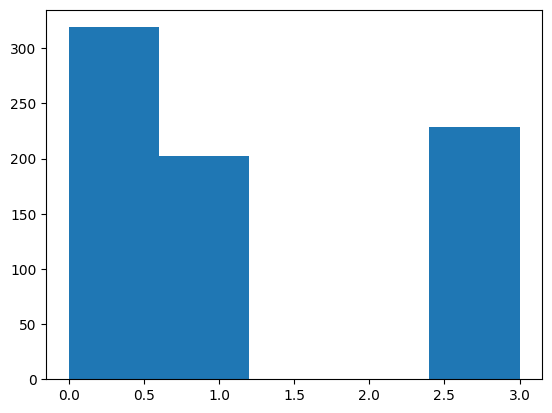

In [24]:
plt.hist(data[0:iteration].experiment.initial_state.flatten(), bins=5)
plt.show()

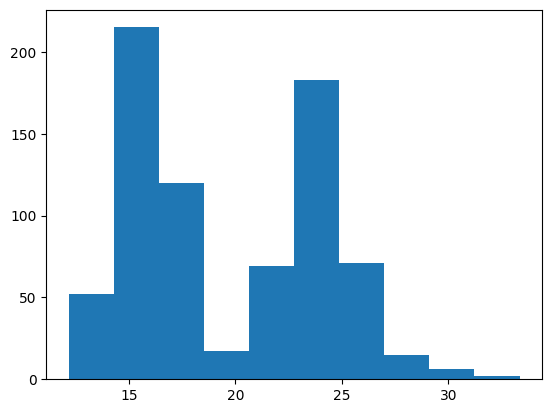

In [26]:
plt.hist(data[0:iteration].experiment.time.flatten())
plt.show()

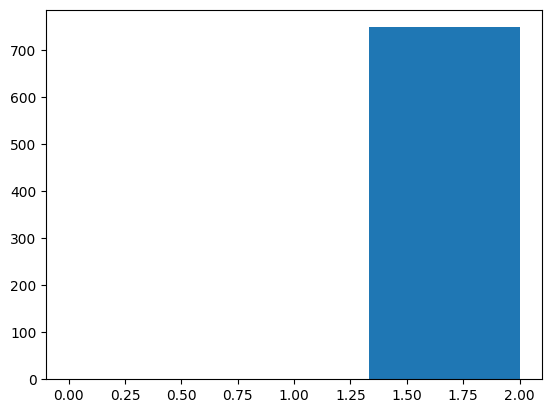

In [27]:
plt.hist(data[0:iteration].experiment.measurement_basis.flatten(), bins=3)
plt.show()

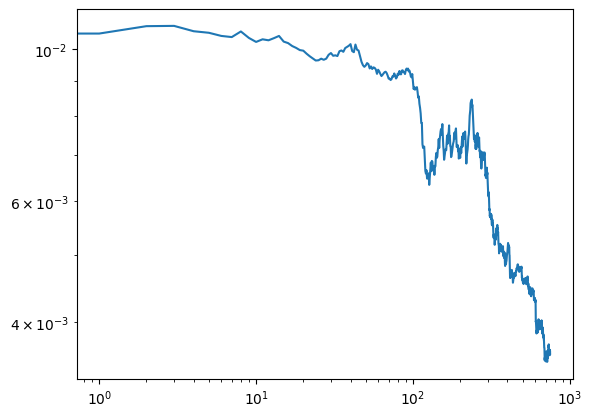

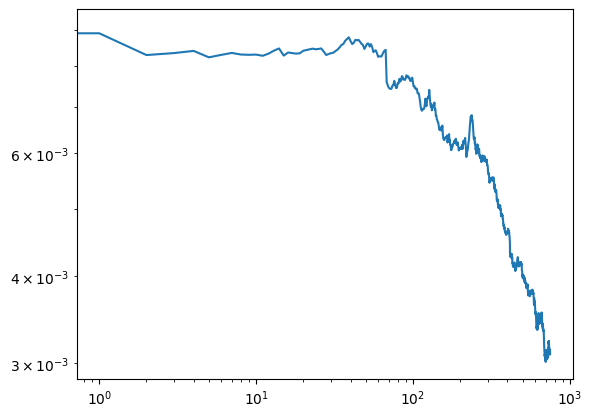

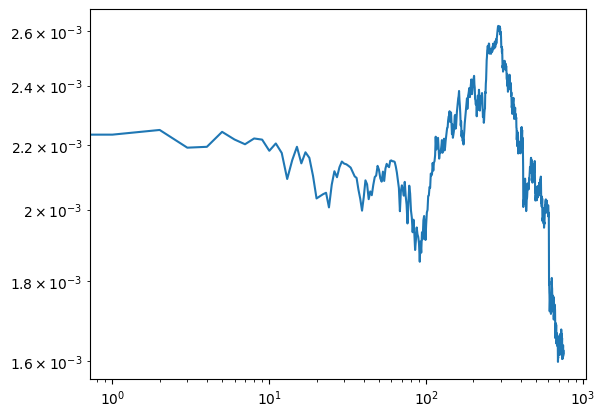

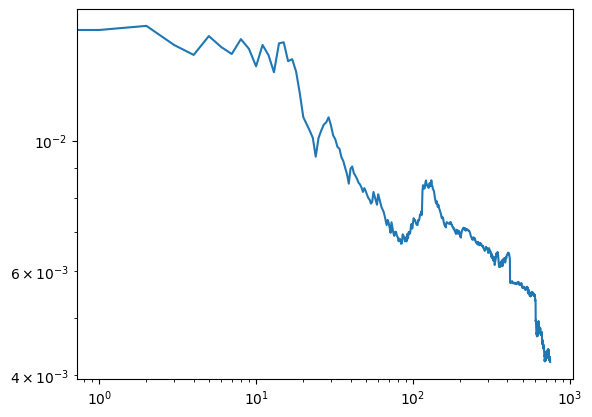

In [29]:
for i in range(4):
    plt.plot(list_covariances[:, i, i])
    plt.loglog()
    plt.show()

In [34]:
iteration

Array(750, dtype=int32, weak_type=True)

[]

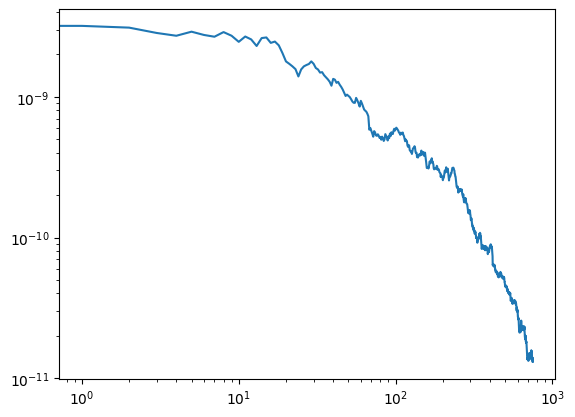

In [33]:
plt.plot(jax.vmap(lambda mat: jnp.linalg.det(mat))(list_covariances))
plt.loglog()

In [35]:
model = SingleDotWeakCouplingGAME()

key = jax.random.key(0)
key, subkey = jax.random.split(key)
boundaries = jnp.array(
    [
        [0.1, 0.5],
        [0.1, 0.5],
        [0.01, 0.2],
        [-0.5, -0.01],
    ]
)
loc = boundaries.mean(axis=1)
scale = boundaries.std(axis=1)


_aux_exps = jax.vmap(lambda e: ExperimentSingleDotWeakCouplingGAME(*e))(
    jnp.repeat(jnp.array([-99, -99, -99])[None, :], N_max_exps, axis=0)
)

_aux_outcomes = jnp.ones(N_max_exps) * 0

aux_data = jax.vmap(lambda exp, outcome: Data(exp, outcome), in_axes=(0, 0))(
    _aux_exps, _aux_outcomes
)


def initialize_distributions(subkey):
    key, subkey = jax.random.split(subkey)
    truncated_norm = tfp.distributions.TruncatedNormal(
        loc=loc, scale=scale / 1.5, low=boundaries[:, 0], high=boundaries[:, 1]
    )

    init_particles_locations = truncated_norm.sample(
        seed=subkey, sample_shape=(no_particles,)
    )
    weights = jnp.ones(no_particles) / no_particles

    dist = Distribution(particles_locations=init_particles_locations, weights=weights)
    iteration = 0
    prob_initial_state = jnp.ones(4) / 4
    prob_measurement_basis = jnp.ones(3) / 3
    return key, iteration, dist, aux_data, prob_initial_state, prob_measurement_basis


# data = aux_data


In [80]:
# inputs = jax.vmap(step, in_axes=(0, 0, 0, 0, 0, 0))(*inputs)

In [161]:
@jax.jit
def replace_log_arrays(
    inputs, covariances_arr, e_values_arr, pr_rho0_arr, pr_basis_arr
):
    keys, iterations, dists, datas, prob_initial_states, prob_measurement_basiss = (
        inputs
    )

    iteration = iterations[0]
    covariances_arr = covariances_arr.at[iteration].set(
        jax.vmap(lambda x: x.cov())(dists)
    )
    e_values_arr = e_values_arr.at[iteration].set(jax.vmap(lambda x: x.ev())(dists))
    pr_rho0_arr = pr_rho0_arr.at[iteration].set(prob_initial_states)
    pr_basis_arr = pr_basis_arr.at[iteration].set(prob_measurement_basiss)

    return covariances_arr, e_values_arr, pr_rho0_arr, pr_basis_arr


In [162]:
jitted_vmap_step = jax.jit(jax.vmap(step, in_axes=(0, 0, 0, 0, 0, 0)))


In [163]:
no_runs = 100
iter_max = 4000
subkeys = jax.random.split(key, no_runs + 1)
key = subkeys[0]
subkeys = subkeys[1:]

covariances_arr = jnp.zeros([N_max_exps, no_runs, 4, 4])
e_values_arr = jnp.zeros([N_max_exps, no_runs, 4])
pr_rho0_arr = jnp.zeros([N_max_exps, no_runs, 4])
pr_basis_arr = jnp.zeros([N_max_exps, no_runs, 3])


carry_args = jax.vmap(initialize_distributions)(subkeys)


In [164]:
for i in range(iter_max):
    carry_args = jitted_vmap_step(*carry_args)
    if i % 25 == 0:
        print(f"Iteration number: {i}")
    covariances_arr, e_values_arr, pr_rho0_arr, pr_basis_arr = replace_log_arrays(
        carry_args, covariances_arr, e_values_arr, pr_rho0_arr, pr_basis_arr
    )

DEBUG:2024-09-11 16:51:37,827:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-11 16:51:37,828:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-11 16:51:37,878:jax._src.lru_cache:107: Cache hit for key: 'jit_step-fa8825529315cbf34b63fd6fe6938b7d32db7e1619794284eb51d06f6157f319'
DEBUG:2024-09-11 16:51:38,697:jax._src.compiler:98: Persistent compilation cache hit for 'jit_step' with key 'jit_step-fa8825529315cbf34b63fd6fe6938b7d32db7e1619794284eb51d06f6157f319'
DEBUG:2024-09-11 16:51:40,429:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-11 16:51:40,430:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-11 16:51:40,431:jax._src.lru_cache:104: Cache miss for key: 'jit_replace_log_arrays-d2e6712adcd75c50

Iteration number: 0
Iteration number: 25
Iteration number: 50
Iteration number: 75
Iteration number: 100
Iteration number: 125
Iteration number: 150
Iteration number: 175
Iteration number: 200
Iteration number: 225
Iteration number: 250
Iteration number: 275
Iteration number: 300
Iteration number: 325
Iteration number: 350
Iteration number: 375
Iteration number: 400
Iteration number: 425
Iteration number: 450
Iteration number: 475
Iteration number: 500
Iteration number: 525
Iteration number: 550
Iteration number: 575
Iteration number: 600
Iteration number: 625
Iteration number: 650
Iteration number: 675
Iteration number: 700
Iteration number: 725
Iteration number: 750
Iteration number: 775
Iteration number: 800
Iteration number: 825
Iteration number: 850
Iteration number: 875
Iteration number: 900
Iteration number: 925
Iteration number: 950
Iteration number: 975
Iteration number: 1000
Iteration number: 1025
Iteration number: 1050
Iteration number: 1075
Iteration number: 1100
Iteration 

In [220]:
import joblib

# joblib.dump([covariances_arr[1:], e_values_arr[1:], pr_rho0_arr[1:], pr_basis_arr[1:], carry_args], filename="summary.job")


DEBUG:2024-09-12 14:00:14,431:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 14:00:14,433:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 14:00:14,434:jax._src.lru_cache:104: Cache miss for key: 'jit_dynamic_slice-24cbb2d343c5bdd320e332e344e50cb0128e450f57a91ee0ded2ff109c91d118'
DEBUG:2024-09-12 14:00:14,470:jax._src.compiler:704: 'jit_dynamic_slice' took at least 0.00 seconds to compile (0.03s)
DEBUG:2024-09-12 14:00:14,502:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 14:00:14,504:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 14:00:14,506:jax._src.lru_cache:104: Cache miss for key: 'jit_dynamic_slice-d101588d2131bf1cc88322e7a5a37bcecaba7348c66d21d582d09394bb949fe0'
DEBUG:2024-

['summary.job']

# DATA ANALYSIS

In [276]:
covariances_arr, e_values_arr, pr_rho0_arr, pr_basis_arr, carry_args = joblib.load(
    "summary.job"
)


# Fix the mess I did with the indexes
aux_cov = np.array(covariances_arr)

another_aux_cov = np.zeros([N_max_exps - 1, 100, 4, 4])

another_aux_cov[1:] = aux_cov

another_aux_cov[0] = another_aux_cov[1]

covariances_arr = jnp.array(another_aux_cov)

data = carry_args[3]

final_iteration = carry_args[1][0]


covariances_arr = covariances_arr[0:final_iteration]

e_values_arr = e_values_arr[0:final_iteration]
pr_rho0_arr = pr_rho0_arr[0:final_iteration]
pr_basis_arr = pr_basis_arr[0:final_iteration]

data = data[:, 0 : final_iteration - 1]


In [318]:
# For a run, I will compute the cumsum

cumsum_times = jnp.cumsum(data.experiment.time, axis=1).squeeze()
print(cumsum_times.shape)

(100, 3999)


In [311]:
from scipy.stats import binned_statistic, binned_statistic_dd

In [319]:
cumsum_times[0].shape

DEBUG:2024-09-12 18:03:36,705:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 18:03:36,706:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 18:03:36,707:jax._src.lru_cache:104: Cache miss for key: 'jit_dynamic_slice-f72969a9b69e08645ecd5025de9483a4731bd80adba0f69f46ae6ff07c483c52'
DEBUG:2024-09-12 18:03:36,718:jax._src.compiler:704: 'jit_dynamic_slice' took at least 0.00 seconds to compile (0.01s)
DEBUG:2024-09-12 18:03:36,726:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 18:03:36,727:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 18:03:36,728:jax._src.lru_cache:104: Cache miss for key: 'jit_squeeze-efa63006ed7e2c349ea9368937c1193a83176e2d30c11643627d847baca3d6e8'
DEBUG:2024-09-12 

(3999,)

In [395]:
cumsum_times_flattened_sorted = np.sort(np.array(cumsum_times).flatten())
indexes_sorted = np.argsort(cumsum_times.flatten())

covariances_flattened_sorted = np.transpose(np.array(covariances_arr[1:]), (1, 0, 2, 3)).reshape(-1, 4, 4)
covariances_flattened_sorted = covariances_flattened_sorted[indexes_sorted, :, :]

In [393]:
covariances_arr.shape

(4000, 100, 4, 4)

In [392]:
cumsum_times.flatt.shape

(100, 3999)

In [391]:
np.sort(covariances_arr, order=indexes_sorted)

ValueError: Cannot specify order when the array has no fields.

DEBUG:2024-09-12 18:22:04,792:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 18:22:04,793:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 18:22:04,795:jax._src.lru_cache:104: Cache miss for key: 'jit__reduce_max-25b43be07e02a579e19d529386c2ba56f938ee3e8d6bb7ff2530cda4ac747dd4'
DEBUG:2024-09-12 18:22:04,834:jax._src.compiler:704: 'jit__reduce_max' took at least 0.00 seconds to compile (0.04s)


Array(399899, dtype=int32)

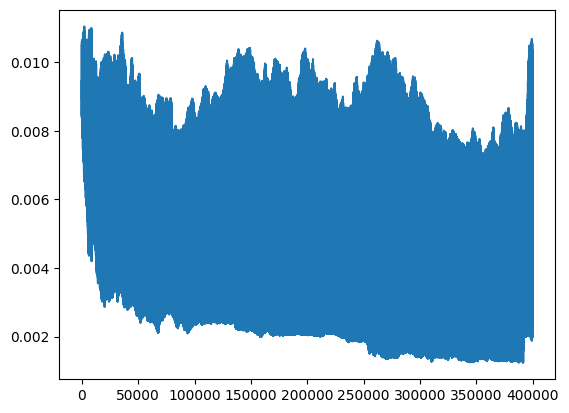

In [396]:
plt.plot(covariances_flattened_sorted[:, 0, 0])

In [367]:
cumsum_times.flatten().shape

(399900,)

In [345]:
binned_statistic(
    x=cumsum_times_flattened_sorted,
    values=covariances_flattened_sorted[:, 0, 0],
    bins=1000,
)

BinnedStatisticResult(statistic=array([0.00472335, 0.00472571, 0.00467394, 0.00459192, 0.00463717,
       0.00470198, 0.00464273, 0.00469149, 0.00481474, 0.00476577,
       0.00465209, 0.00467105, 0.00461116, 0.00472853, 0.00461437,
       0.0045967 , 0.00461417, 0.00458789, 0.00467201, 0.00474509,
       0.00474521, 0.00474028, 0.00471688, 0.00477733, 0.00471166,
       0.00465034, 0.00467949, 0.00478193, 0.00468658, 0.0047282 ,
       0.00467056, 0.0047056 , 0.00469014, 0.0046134 , 0.00473082,
       0.00475561, 0.00465252, 0.00467882, 0.00459386, 0.00477881,
       0.00466132, 0.00465101, 0.00472791, 0.0047191 , 0.00468588,
       0.00467172, 0.00476109, 0.00465617, 0.00468625, 0.00476063,
       0.00466023, 0.00465704, 0.00465407, 0.00475548, 0.00468616,
       0.00470071, 0.00474724, 0.00465574, 0.00467855, 0.00467131,
       0.00467802, 0.00478212, 0.00464801, 0.00468926, 0.00471247,
       0.0047637 , 0.00467534, 0.00470549, 0.00466872, 0.00461019,
       0.00460791, 0.00465973,

In [397]:
no_bins = 1000

cov_mean_list = []
cov_std_list = []

for i in range(4):
    cov_mean_row_list = []
    cov_std_row_list = []

    for j in range(4):
        cov_mean_row_list.append(
            binned_statistic(
                x=cumsum_times_flattened_sorted,
                values=covariances_flattened_sorted[:, i, j],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        cov_std_row_list.append(
            binned_statistic(
                cumsum_times_flattened_sorted,
                covariances_flattened_sorted[:, i, j],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    cov_mean_list.append(cov_mean_row_list)
    cov_std_list.append(cov_std_row_list)
cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

cum_times_binned, _, _ = binned_statistic(
        cumsum_times_flattened_sorted, cumsum_times_flattened_sorted, statistic="mean", bins=no_bins
    )

# binned_statistic(x=cumsum_times_flattened_sorted, values=covariances_flattened_sorted[:, 0, 0], bins=1000)

In [362]:
covariances_arr[:, 0]

(4000, 100, 4, 4)

In [ ]:
plt.fill_between()

DEBUG:2024-09-12 18:50:36,810:jax._src.compiler:166: get_compile_options: num_replicas=1 num_partitions=1 device_assignment=[[CudaDevice(id=0)]]
DEBUG:2024-09-12 18:50:36,812:jax._src.compiler:230: get_compile_options XLA-AutoFDO profile: using XLA-AutoFDO profile version -1
DEBUG:2024-09-12 18:50:36,813:jax._src.lru_cache:104: Cache miss for key: 'jit_ravel-f3952fc17c458a70a1a129f2cb876ef283021b020736370cb746720736dc3fac'
DEBUG:2024-09-12 18:50:36,824:jax._src.compiler:704: 'jit_ravel' took at least 0.00 seconds to compile (0.01s)


(array([1.80353e+05, 0.00000e+00, 0.00000e+00, 1.08040e+05, 0.00000e+00,
        0.00000e+00, 5.40000e+01, 0.00000e+00, 0.00000e+00, 1.11453e+05]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

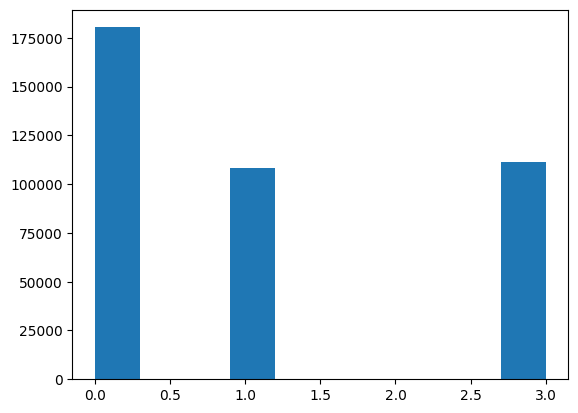

In [416]:
plt.hist(np.array(data.experiment.initial_state.flatten()))

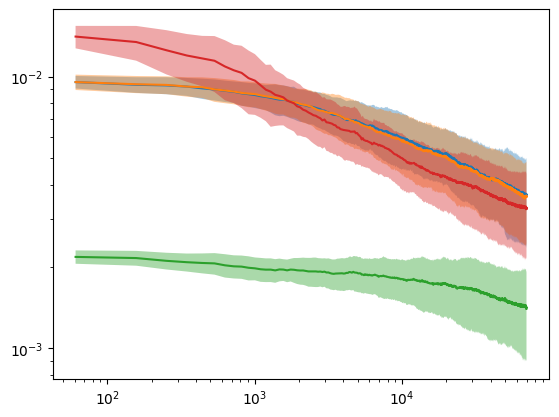

In [412]:
end_idx = (np.argwhere(cum_times_binned<7e4)[-1]).squeeze()
for i in range(4):
    times = cum_times_binned[0:end_idx]
    mean_line =  cov_mean_list[0:end_idx, i, i]
    std_line = cov_std_list[0:end_idx, i, i]
    plt.plot(times, mean_line)
    plt.fill_between(times, mean_line - std_line, mean_line+ std_line, alpha=0.4)
    # plt.plot(covariances_arr[:, 0, i, i])
    plt.loglog()